In [1]:
!pip install -q monai

# Install Grad-CAM for explainability
!pip install -q grad-cam

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
set_seed(42)


print("SETUP COMPLETE")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 27.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.0 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
SETUP COMPLETE
PyTorch version: 2.10.0+cu128
GPU Available: True
GPU: Tesla T4


## Load Saved Data from Notebook 1

In [2]:
dataset_path = "/kaggle/input/datasets/asadchanna/isic-dataset/pure_project_data"  

# Load the CSV files
train_data = pd.read_csv(os.path.join(dataset_path, "train_data.csv"))
val_data = pd.read_csv(os.path.join(dataset_path, "val_data.csv"))
train_bboxes = pd.read_csv(os.path.join(dataset_path, "train_bboxes.csv"))
val_bboxes = pd.read_csv(os.path.join(dataset_path, "val_bboxes.csv"))

print("📁 DATA LOADED SUCCESSFULLY")

print(f"Training images: {len(train_data)}")
print(f"Validation images: {len(val_data)}")
print(f"Training bounding boxes: {len(train_bboxes)}")
print(f"Validation bounding boxes: {len(val_bboxes)}")

# Display first few rows
print("\nTraining data sample:")
train_data.head(3)

📁 DATA LOADED SUCCESSFULLY
Training images: 2075
Validation images: 519
Training bounding boxes: 2075
Validation bounding boxes: 519

Training data sample:


,image_id,image_path,mask_path
0,ISIC_0010226,/kaggle/input/datasets/tschandl/isic2018-chall...,/kaggle/input/datasets/tschandl/isic2018-chall...
1,ISIC_0014506,/kaggle/input/datasets/tschandl/isic2018-chall...,/kaggle/input/datasets/tschandl/isic2018-chall...
2,ISIC_0010069,/kaggle/input/datasets/tschandl/isic2018-chall...,/kaggle/input/datasets/tschandl/isic2018-chall...


## Creating dataset class for loading images

In [3]:
class SkinLesionDataset(Dataset):
    """Simple dataset class to load images and masks"""
    
    def __init__(self, df, target_size=(256, 256)):
        """
        Args:
            df: DataFrame with 'image_id' column (not full paths)
            target_size: resize all images to this size (height, width)
        """
        self.df = df.reset_index(drop=True)
        self.target_size = target_size
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Get image_id
        image_id = self.df.iloc[idx]['image_id']
        
        # Build paths using your original dataset location
        base_path = "/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation"
        
        img_path = os.path.join(base_path, "ISIC2018_Task1-2_Training_Input", f"{image_id}.jpg")
        mask_path = os.path.join(base_path, "ISIC2018_Task1_Training_GroundTruth", f"{image_id}_segmentation.png")
        
        # Check if file exists, if not try alternative mask extension
        if not os.path.exists(mask_path):
            mask_path = os.path.join(base_path, "ISIC2018_Task1_Training_GroundTruth", f"{image_id}.png")
        
        # Load image
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image not found: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.target_size)
        image = image / 255.0  # Normalize to [0, 1]
        
        # Load mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"Mask not found: {mask_path}")
        mask = cv2.resize(mask, self.target_size)
        
        # Convert mask to binary (0 or 1)
        mask = (mask > 0).astype(np.float32)
        
        # Convert to PyTorch tensors
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()
        
        return image, mask

# Create datasets
train_dataset = SkinLesionDataset(train_data)
val_dataset = SkinLesionDataset(val_data)

# Create data loaders
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


print(" DATASET READY")

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print("=" * 50)

# Test one batch
try:
    sample_image, sample_mask = next(iter(train_loader))
    print(f"\nSuccess! Loaded one batch")
    print(f"Sample image shape: {sample_image.shape}")
    print(f"Sample mask shape: {sample_mask.shape}")
    print(f"Image range: [{sample_image.min():.2f}, {sample_image.max():.2f}]")
    print(f"Mask range: [{sample_mask.min():.0f}, {sample_mask.max():.0f}]")
except Exception as e:
    print(f"\nError: {e}")
    print("\nCheck that your dataset from Notebook 1 has 'image_id' column")
    print(train_data.head())

 DATASET READY
Training samples: 2075
Validation samples: 519
Batch size: 8
Training batches per epoch: 260
Validation batches: 65

Success! Loaded one batch
Sample image shape: torch.Size([8, 3, 256, 256])
Sample mask shape: torch.Size([8, 1, 256, 256])
Image range: [0.00, 1.00]
Mask range: [0, 1]


## Define U-Net Model

#### Component	 |   Explanation

#### DoubleConv	 |  Two convolution layers with batch normalization
#### Down	     |  MaxPooling + DoubleConv (Encoder path)
#### Up	         |  Upsampling + DoubleConv (Decoder path)
#### UNet        |   Full architecture connecting encoder and decoder with skip connections

In [4]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(Conv -> BN -> ReLU) x 2"""
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)

class Down(nn.Module):
    """Downscaling with MaxPool then DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
    
    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super(Up, self).__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)
    
    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Handle size mismatches
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    """Final convolution to get 1 channel output"""
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    """Full U-Net Model"""
    def __init__(self, n_channels=3, n_classes=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        
        # Encoder (Downsampling)
        self.inc = DoubleConv(n_channels, features[0])
        self.down1 = Down(features[0], features[1])
        self.down2 = Down(features[1], features[2])
        self.down3 = Down(features[2], features[3])
        self.down4 = Down(features[3], features[3] * 2)
        
        # Decoder (Upsampling)
        self.up1 = Up(features[3] * 2, features[3])
        self.up2 = Up(features[3], features[2])
        self.up3 = Up(features[2], features[1])
        self.up4 = Up(features[1], features[0])
        
        # Output
        self.outc = OutConv(features[0], n_classes)
    
    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        # Decoder
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        # Output
        logits = self.outc(x)
        return torch.sigmoid(logits)  # Sigmoid for binary segmentation

# Create model and move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(n_channels=3, n_classes=1).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("U-NET MODEL CREATED")

print(f"Device: {device}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


# Test forward pass with a dummy input
dummy_input = torch.randn(1, 3, 256, 256).to(device)
dummy_output = model(dummy_input)
print(f"\n Forward pass successful")
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {dummy_output.shape}")

U-NET MODEL CREATED
Device: cuda
Total parameters: 31,043,521
Trainable parameters: 31,043,521

 Forward pass successful
Input shape: torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])


## Defining Loss Function and Training Setup

In [5]:
class DiceLoss(nn.Module):
    """Dice Loss for segmentation - measures overlap between prediction and ground truth"""
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        # Flatten predictions and targets
        pred = pred.view(-1)
        target = target.view(-1)
        
        # Calculate intersection
        intersection = (pred * target).sum()
        
        # Calculate Dice coefficient
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        
        # Return Dice loss (1 - Dice coefficient)
        return 1 - dice

class CombinedLoss(nn.Module):
    """Combined BCE Loss + Dice Loss (best of both worlds)"""
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super(CombinedLoss, self).__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce_loss = nn.BCELoss()
        self.dice_loss = DiceLoss()
    
    def forward(self, pred, target):
        bce = self.bce_loss(pred, target)
        dice = self.dice_loss(pred, target)
        return self.bce_weight * bce + self.dice_weight * dice

# Training function
def train_one_epoch(model, train_loader, optimizer, criterion, device):
    """Train model for one epoch"""
    model.train()
    total_loss = 0
    
    for batch_idx, (images, masks) in enumerate(train_loader):
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Print progress every 50 batches
        if batch_idx % 50 == 0:
            print(f"  Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")
    
    return total_loss / len(train_loader)

# Validation function
def validate(model, val_loader, criterion, device):
    """Validate model"""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()
    
    return total_loss / len(val_loader)

# Calculate Dice Score (for evaluation)
def calculate_dice_score(model, val_loader, device):
    """Calculate Dice Score on validation set"""
    model.eval()
    dice_scores = []
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            
            # Convert to binary (0 or 1)
            pred_binary = (outputs > 0.5).float()
            
            # Calculate Dice for each image in batch
            for i in range(pred_binary.shape[0]):
                pred_flat = pred_binary[i].view(-1)
                mask_flat = masks[i].view(-1)
                
                intersection = (pred_flat * mask_flat).sum()
                dice = (2. * intersection) / (pred_flat.sum() + mask_flat.sum() + 1e-6)
                dice_scores.append(dice.item())
    
    return np.mean(dice_scores)

# Setup training parameters
criterion = CombinedLoss(bce_weight=0.5, dice_weight=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 10  # You can increase for better results

print("TRAINING SETUP COMPLETE")

print(f"Loss function: Combined (BCE + Dice)")
print(f"Optimizer: Adam (learning rate = 1e-4)")
print(f"Number of epochs: {num_epochs}")
print(f"Total training batches: {len(train_loader)}")
print(f"Total validation batches: {len(val_loader)}")

TRAINING SETUP COMPLETE
Loss function: Combined (BCE + Dice)
Optimizer: Adam (learning rate = 1e-4)
Number of epochs: 10
Total training batches: 260
Total validation batches: 65


## Training the model

STARTING TRAINING
Total epochs: 10
Training samples: 2075
Validation samples: 519

 Epoch 1/10
----------------------------------------
  Batch 0/260, Loss: 0.6793
  Batch 50/260, Loss: 0.4708
  Batch 100/260, Loss: 0.4137
  Batch 150/260, Loss: 0.4885
  Batch 200/260, Loss: 0.3362
  Batch 250/260, Loss: 0.3106
Train Loss: 0.4169
Val Loss: 0.3494
Dice Score: 0.7477
Saved new best model! (Dice: 0.7477)

 Epoch 2/10
----------------------------------------
  Batch 0/260, Loss: 0.3485
  Batch 50/260, Loss: 0.3342
  Batch 100/260, Loss: 0.3133
  Batch 150/260, Loss: 0.2922
  Batch 200/260, Loss: 0.2868
  Batch 250/260, Loss: 0.2312
Train Loss: 0.3104
Val Loss: 0.2819
Dice Score: 0.7808
Saved new best model! (Dice: 0.7808)

 Epoch 3/10
----------------------------------------
  Batch 0/260, Loss: 0.3764
  Batch 50/260, Loss: 0.3349
  Batch 100/260, Loss: 0.2423
  Batch 150/260, Loss: 0.3340
  Batch 200/260, Loss: 0.1773
  Batch 250/260, Loss: 0.2741
Train Loss: 0.2584
Val Loss: 0.2522
Dice 

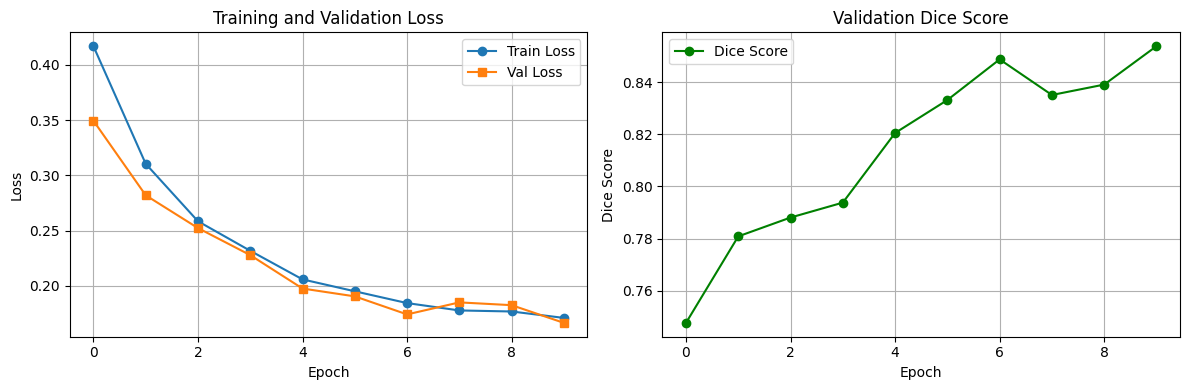


Training curves saved to: /kaggle/working/project_model/training_curves.png


In [6]:

model_dir = "/kaggle/working/project_model"
os.makedirs(model_dir, exist_ok=True)

# Track training history
train_losses = []
val_losses = []
val_dice_scores = []
best_dice = 0.0

print("STARTING TRAINING")
print(f"Total epochs: {num_epochs}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print("=" * 50)

for epoch in range(num_epochs):
    print(f"\n Epoch {epoch+1}/{num_epochs}")
    print("-" * 40)
    
    # Train
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    train_losses.append(train_loss)
    
    # Validate
    val_loss = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    
    # Calculate Dice Score
    dice_score = calculate_dice_score(model, val_loader, device)
    val_dice_scores.append(dice_score)
    
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Dice Score: {dice_score:.4f}")
    
    # Save best model
    if dice_score > best_dice:
        best_dice = dice_score
        torch.save(model.state_dict(), os.path.join(model_dir, "best_unet_model.pth"))
        print(f"Saved new best model! (Dice: {best_dice:.4f})")

print("TRAINING COMPLETE!")

print(f"Best Dice Score: {best_dice:.4f}")
print(f"Model saved to: {model_dir}/best_unet_model.pth")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Dice Score plot
axes[1].plot(val_dice_scores, label='Dice Score', color='green', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].set_title('Validation Dice Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(model_dir, "training_curves.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTraining curves saved to: {model_dir}/training_curves.png")

## testing model

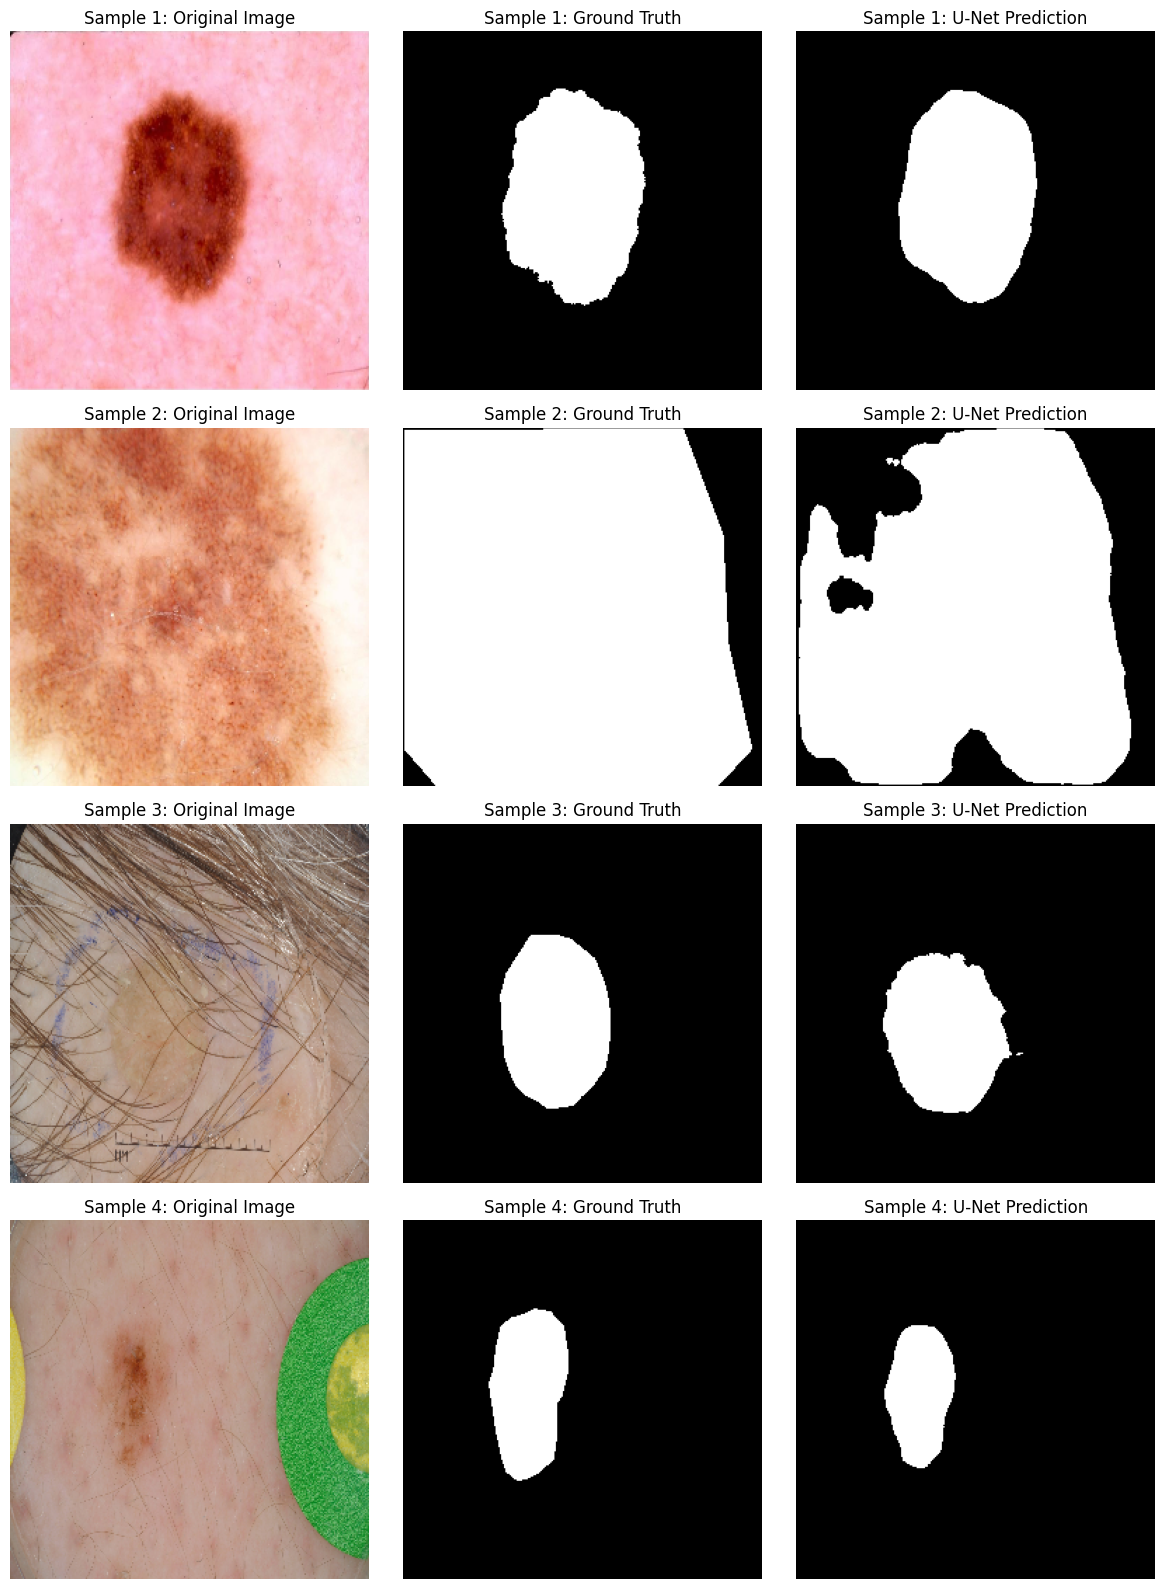

PREDICTION FIGURES SAVED
Location: /kaggle/working/project_predictions/unet_predictions.png

FINAL MODEL PERFORMANCE:
Best Dice Score: 0.8538
Interpretation: 85.4% overlap with ground truth

Metrics saved to: /kaggle/working/project_model/model_metrics.csv


In [7]:
model.load_state_dict(torch.load(os.path.join(model_dir, "best_unet_model.pth")))
model.eval()

# Create folder for prediction figures
pred_dir = "/kaggle/working/project_predictions"
os.makedirs(pred_dir, exist_ok=True)

# Get 4 sample images from validation set
num_samples = 4
sample_images = []
sample_masks = []
sample_predictions = []

with torch.no_grad():
    for i, (images, masks) in enumerate(val_loader):
        if i >= num_samples:
            break
        images = images.to(device)
        outputs = model(images)
        
        # Store first image from each batch
        sample_images.append(images[0].cpu())
        sample_masks.append(masks[0].cpu())
        sample_predictions.append(outputs[0].cpu())

# Create visualization figure
fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

for idx in range(num_samples):
    # Get image, mask, prediction
    img = sample_images[idx].permute(1, 2, 0).numpy()
    mask = sample_masks[idx][0].numpy()
    pred = sample_predictions[idx][0].numpy()
    
    # Convert prediction to binary
    pred_binary = (pred > 0.5).astype(np.float32)
    
    # Plot original image
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f"Sample {idx+1}: Original Image")
    axes[idx, 0].axis('off')
    
    # Plot ground truth mask
    axes[idx, 1].imshow(mask, cmap='gray')
    axes[idx, 1].set_title(f"Sample {idx+1}: Ground Truth")
    axes[idx, 1].axis('off')
    
    # Plot prediction
    axes[idx, 2].imshow(pred_binary, cmap='gray')
    axes[idx, 2].set_title(f"Sample {idx+1}: U-Net Prediction")
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(pred_dir, "unet_predictions.png"), dpi=150, bbox_inches='tight')
plt.show()

print("PREDICTION FIGURES SAVED")
print(f"Location: {pred_dir}/unet_predictions.png")

# Calculate and display final metrics
print("\nFINAL MODEL PERFORMANCE:")

print(f"Best Dice Score: {best_dice:.4f}")
print(f"Interpretation: {best_dice*100:.1f}% overlap with ground truth")

# Save metrics to CSV for report
metrics_df = pd.DataFrame({
    'Metric': ['Best Dice Score', 'Final Train Loss', 'Final Val Loss'],
    'Value': [best_dice, train_losses[-1], val_losses[-1]]
})
metrics_df.to_csv(os.path.join(model_dir, "model_metrics.csv"), index=False)
print(f"\nMetrics saved to: {model_dir}/model_metrics.csv")

## Grad-CAM

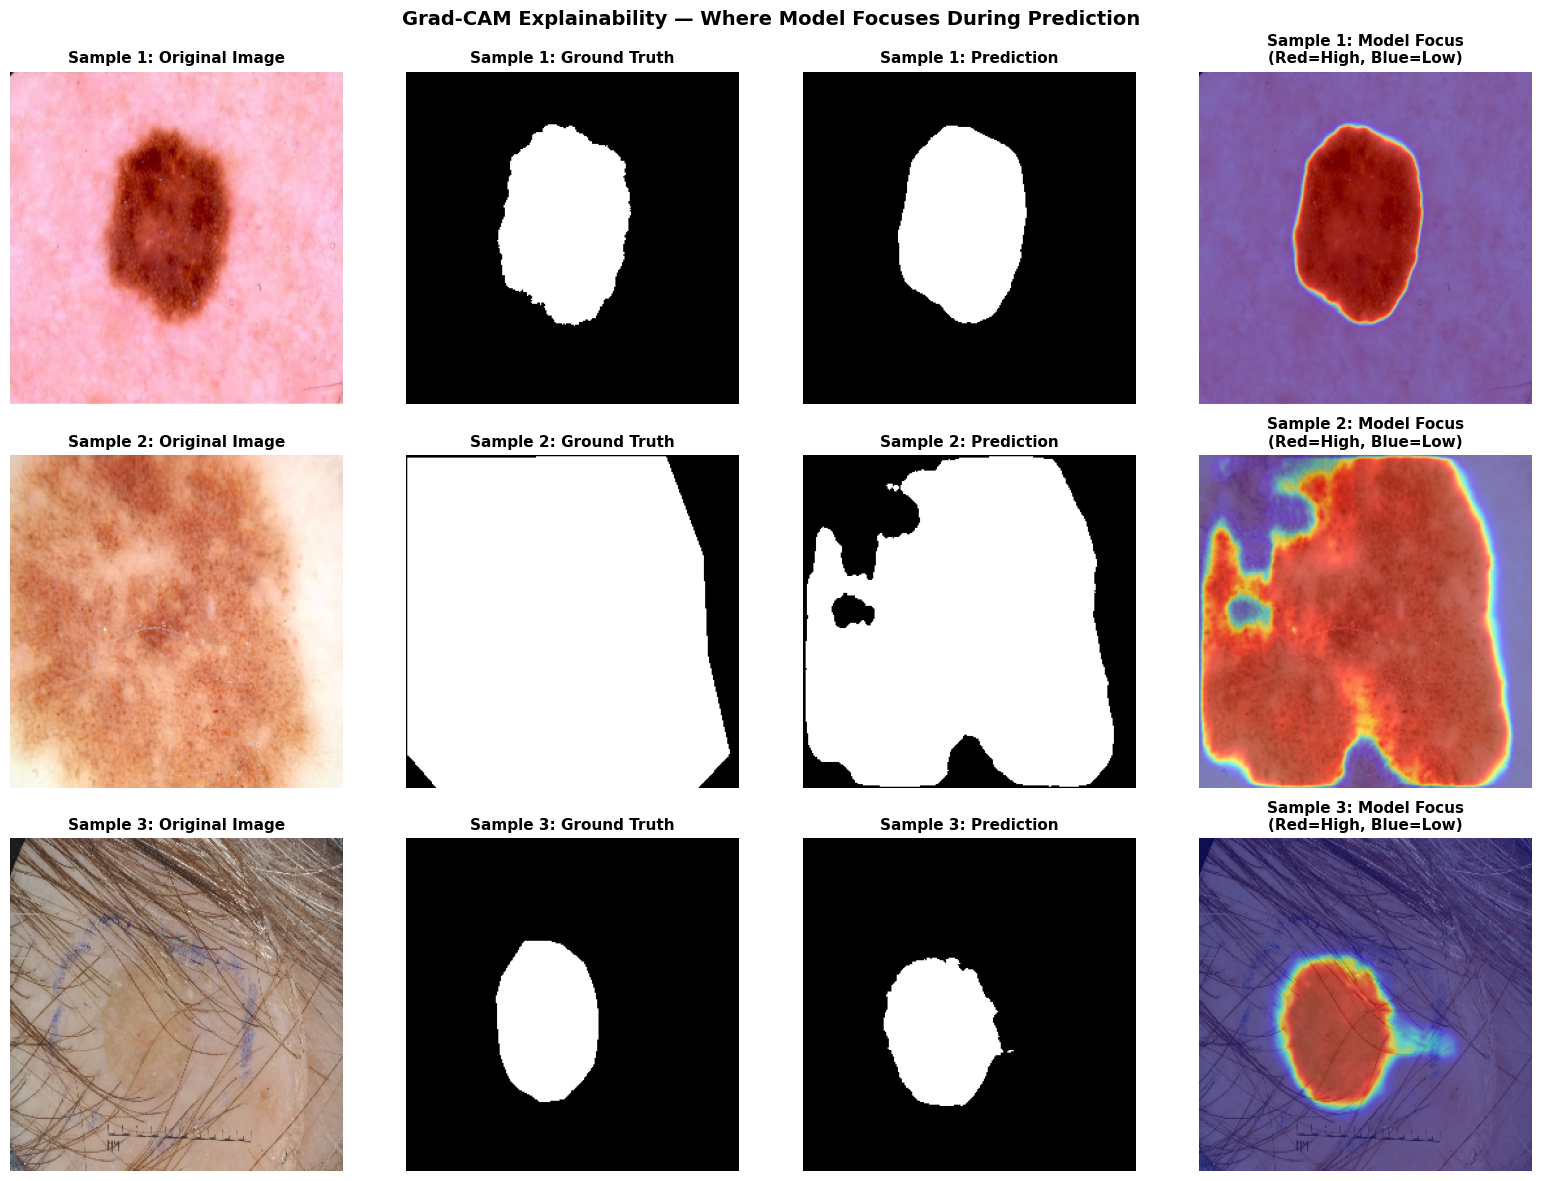

GRAD-CAM HEATMAPS GENERATED SUCCESSFULLY
Saved: /kaggle/working/gradcam_heatmaps.png

How to read the heatmap:
   Red/Yellow  = Model focuses HERE (important region)
   Blue/Purple = Model ignores this region

Saving prediction comparison figure...


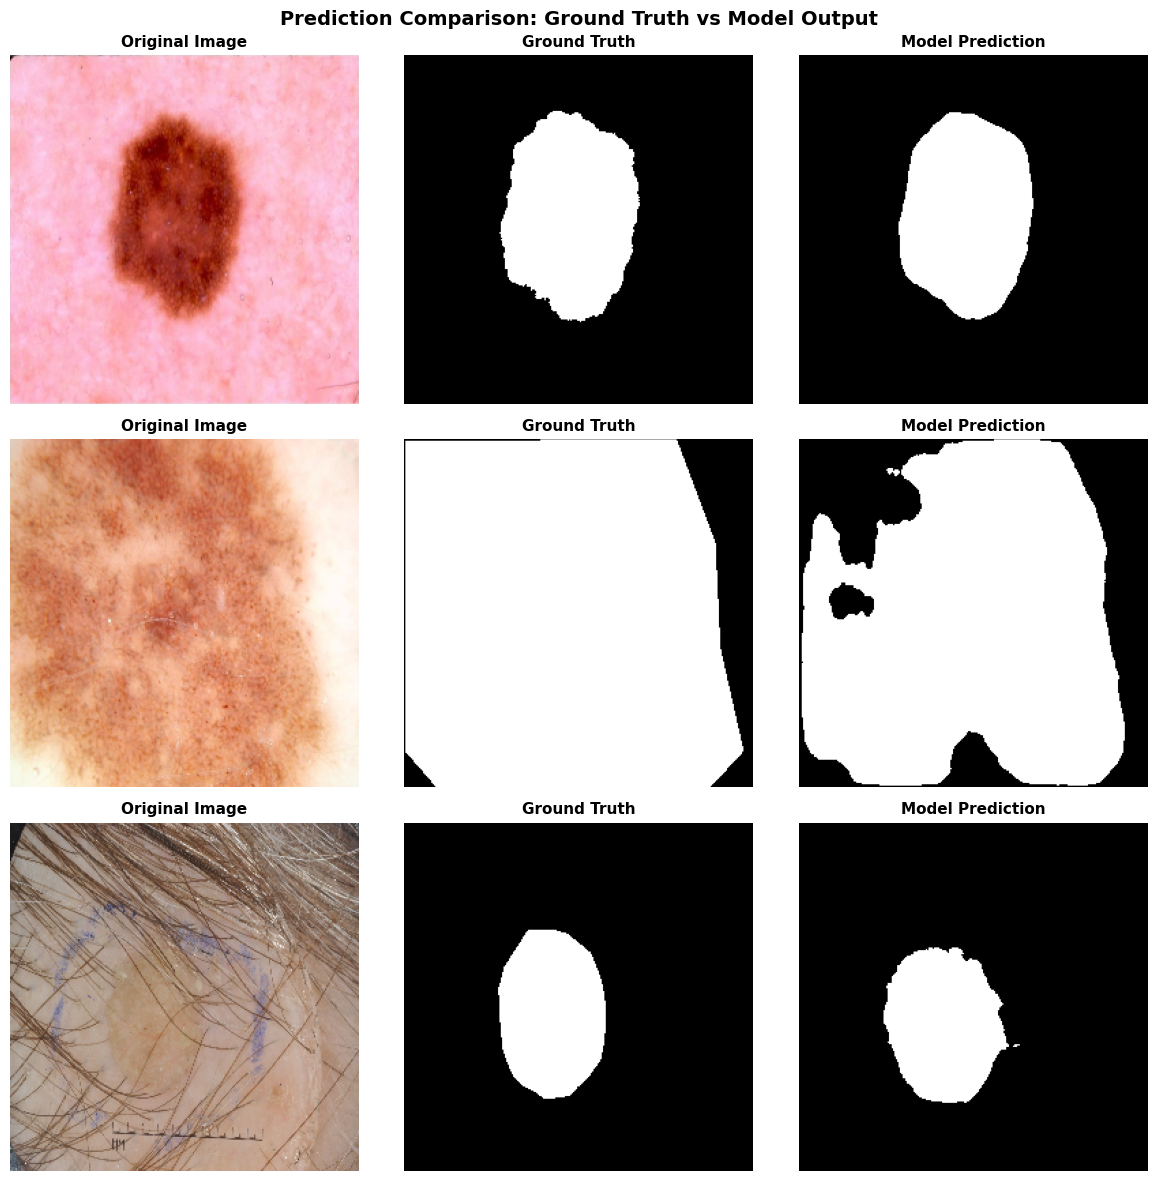

Saved: /kaggle/working/predictions_comparison.png


In [12]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

# ── Get sample images from validation set ────────────────────────
num_samples = 3
sample_images = []
sample_masks = []
sample_predictions = []

with torch.no_grad():
    for i, (images, masks) in enumerate(val_loader):
        if i >= num_samples:
            break
        sample_images.append(images[0].cpu())
        sample_masks.append(masks[0].cpu())
        images = images.to(device)
        outputs = model(images)
        sample_predictions.append(outputs[0].cpu())

# ── Grad-CAM Visualization ────────────────────────────────────────
fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))

for idx in range(num_samples):

    # ── Get image ─────────────────────────────────────────────────
    img_tensor = sample_images[idx]
    img_np = img_tensor.permute(1, 2, 0).numpy()

    # Normalize image for visualization if needed
    if img_np.max() > 1.0:
        img_np = img_np / 255.0
    img_np = np.clip(img_np, 0, 1)

    # ── Prepare input ─────────────────────────────────────────────
    input_tensor = img_tensor.unsqueeze(0).to(device)
    input_tensor.requires_grad_(True)

    # ── Forward pass ──────────────────────────────────────────────
    model.eval()
    model.zero_grad()
    output = model(input_tensor)

    # ── Backward pass ─────────────────────────────────────────────
    target = output.max()
    target.backward()

    # ── Extract gradients safely ──────────────────────────────────
    try:
        gradients = model.up4.conv.conv[-2].weight.grad

        if gradients is not None:
            grad_np = gradients.abs().detach().cpu().numpy()

            # Handle any gradient shape
            if grad_np.ndim == 4:
                heatmap = grad_np.mean(axis=(0, 1))   # → (H, W)
            elif grad_np.ndim == 3:
                heatmap = grad_np.mean(axis=0)         # → (H, W)
            elif grad_np.ndim == 2:
                heatmap = grad_np                      # already (H, W)
            else:
                # Fallback for 1D or unexpected shape
                heatmap = output[0][0].detach().cpu().numpy()

        else:
            # No gradients — use prediction as heatmap
            heatmap = output[0][0].detach().cpu().numpy()

    except Exception as e:
        print(f"Grad-CAM failed for sample {idx+1}: {e}")
        print("Using prediction as fallback heatmap...")
        heatmap = output[0][0].detach().cpu().numpy()

    # ── Resize heatmap to image size ──────────────────────────────
    h, w = img_np.shape[:2]
    heatmap = cv2.resize(heatmap.astype(np.float32), (w, h))

    # ── Normalize heatmap to 0-1 ──────────────────────────────────
    heatmap = (heatmap - heatmap.min()) / (
        heatmap.max() - heatmap.min() + 1e-8
    )

    # ── Create colored heatmap overlay ───────────────────────────
    heatmap_colored = cv2.applyColorMap(
        (heatmap * 255).astype(np.uint8),
        cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    heatmap_colored = heatmap_colored.astype(np.float32) / 255.0

    # ── Overlay heatmap on image ──────────────────────────────────
    if img_np.ndim == 2:
        img_rgb = np.stack([img_np] * 3, axis=-1)
    elif img_np.shape[-1] == 1:
        img_rgb = np.concatenate([img_np] * 3, axis=-1)
    else:
        img_rgb = img_np

    visualization = 0.5 * img_rgb + 0.5 * heatmap_colored
    visualization = np.clip(visualization, 0, 1)

    # ── Get prediction and mask ───────────────────────────────────
    pred      = sample_predictions[idx][0].numpy()
    pred_bin  = (pred > 0.5).astype(np.float32)
    mask      = sample_masks[idx][0].numpy()

    # ── Plot ──────────────────────────────────────────────────────
    # Column 1 — Original Image
    axes[idx, 0].imshow(img_rgb)
    axes[idx, 0].set_title(f"Sample {idx+1}: Original Image",
                            fontsize=11, fontweight='bold')
    axes[idx, 0].axis('off')

    # Column 2 — Ground Truth
    axes[idx, 1].imshow(mask, cmap='gray')
    axes[idx, 1].set_title(f"Sample {idx+1}: Ground Truth",
                            fontsize=11, fontweight='bold')
    axes[idx, 1].axis('off')

    # Column 3 — Prediction
    axes[idx, 2].imshow(pred_bin, cmap='gray')
    axes[idx, 2].set_title(f"Sample {idx+1}: Prediction",
                            fontsize=11, fontweight='bold')
    axes[idx, 2].axis('off')

    # Column 4 — Grad-CAM Heatmap
    axes[idx, 3].imshow(visualization)
    axes[idx, 3].set_title(f"Sample {idx+1}: Model Focus\n(Red=High, Blue=Low)",
                            fontsize=11, fontweight='bold')
    axes[idx, 3].axis('off')

plt.suptitle(
    'Grad-CAM Explainability — Where Model Focuses During Prediction',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    "/kaggle/working/gradcam_heatmaps.png",
    dpi=150,
    bbox_inches='tight'
)
plt.show()

print("GRAD-CAM HEATMAPS GENERATED SUCCESSFULLY")

print("Saved: /kaggle/working/gradcam_heatmaps.png")
print()
print("How to read the heatmap:")
print("   Red/Yellow  = Model focuses HERE (important region)")
print("   Blue/Purple = Model ignores this region")

# ── Bonus: Simple Prediction Comparison ──────────────────────────
print("\nSaving prediction comparison figure...")

fig2, axes2 = plt.subplots(3, 3, figsize=(12, 12))

for idx in range(3):
    img_np2  = sample_images[idx].permute(1, 2, 0).numpy()
    img_np2  = np.clip(img_np2, 0, 1)
    mask2    = sample_masks[idx][0].numpy()
    pred2    = sample_predictions[idx][0].numpy()
    pred_bin2 = (pred2 > 0.5).astype(np.float32)

    if img_np2.ndim == 2:
        img_np2 = np.stack([img_np2] * 3, axis=-1)
    elif img_np2.shape[-1] == 1:
        img_np2 = np.concatenate([img_np2] * 3, axis=-1)

    axes2[idx, 0].imshow(img_np2)
    axes2[idx, 0].set_title('Original Image',
                             fontsize=11, fontweight='bold')
    axes2[idx, 0].axis('off')

    axes2[idx, 1].imshow(mask2, cmap='gray')
    axes2[idx, 1].set_title('Ground Truth',
                             fontsize=11, fontweight='bold')
    axes2[idx, 1].axis('off')

    axes2[idx, 2].imshow(pred_bin2, cmap='gray')
    axes2[idx, 2].set_title('Model Prediction',
                             fontsize=11, fontweight='bold')
    axes2[idx, 2].axis('off')

plt.suptitle(
    'Prediction Comparison: Ground Truth vs Model Output',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    "/kaggle/working/predictions_comparison.png",
    dpi=150,
    bbox_inches='tight'
)
plt.show()

print("Saved: /kaggle/working/predictions_comparison.png")